In [8]:
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt

from core.data import CompressionMetrics
from core.utils import convert_to_gray_scale
from core.image import compress_image, reconstruct_image

In [9]:
img_rgb = iio.imread("sources/garden_table.png").astype(np.float32)
img_gray = convert_to_gray_scale(img_rgb)

In [10]:
# Hyperparameters
lp_degree = 0.5
block_size = 100
cutoff = "energy"
poly_degrees = np.arange(22, 42, 2) - 1

In [12]:
# Loop
metrics_list = []
img_gray_rec_list = []
for poly_degree in poly_degrees:
    c, X_design, rescale = compress_image(
        image=img_gray,
        poly_degree=poly_degree,
        block_size=block_size,
        lp_degree=lp_degree,
        lasso=False,
        cutoff=cutoff,
    )
    img_gray_rec = reconstruct_image(c, X_design, rescale)
    metrics_list.append(CompressionMetrics(img_gray, img_gray_rec, c))
    img_gray_rec_list.append(img_gray_rec)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 576 out of 576 | elapsed:    0.3s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 576 out of 576 | elapsed:    0.2s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 576 out of 576 | elapsed:    0.2s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 576 out of 576 | elapsed:    0.3s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 576 out of 576 | elapsed:    0.3s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 576 out of 576 | elapsed:    0.3s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 576 out of 576 | elapsed:    0.3s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 576 out of 576 | elapsed:    0.5s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 576 out of 576 | elapsed:    0.4s finished


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 576 out of 576 | elapsed:    0.5s finished


In [13]:
# Extract values
psnr_values = [m.psnr for m in metrics_list]
compression_ratios = [m.compression_ratio for m in metrics_list]
space_saved_values = [m.space_saved for m in metrics_list]

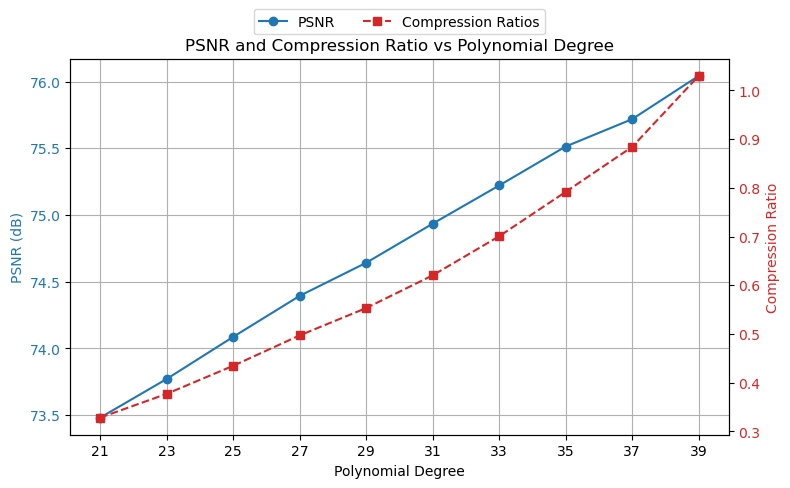

In [14]:
# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot PSNR on primary y-axis
ln1 = ax1.plot(poly_degrees, psnr_values, marker="o", linestyle="-", color="tab:blue", label="PSNR")
ax1.set_xlabel("Polynomial Degree")
ax1.set_ylabel("PSNR (dB)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True)
ax1.set_xticks(poly_degrees)

# Plot space saved on secondary y-axis
ax2 = ax1.twinx()
ln2 = ax2.plot(poly_degrees, compression_ratios, marker="s", linestyle="--", color="tab:red", label="Compression Ratios")
ax2.set_ylabel("Compression Ratio", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# Combine legends and place outside top-left
lines = ln1 + ln2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=2)

plt.title("PSNR and Compression Ratio vs Polynomial Degree")
plt.tight_layout()
# plt.savefig("plots/psnr__pinv__bs=%s__cutoff=%s__p=%s__pd=%s-%s.png" % (block_size, cutoff, lp_degree, poly_degrees[0], poly_degrees[9]))
plt.show()


# Plotting PSNR (dB) vs Space Saved (%)

In [ ]:
# # Create figure and primary axis
# fig, ax = plt.subplots(figsize=(8, 5))

# # Plot PSNR vs space saved
# ax.plot(psnr_values, space_saved_values, marker="o", linestyle="-")
# ax.set_xlabel("PSNR (dB)")
# ax.set_ylabel("Space Saved (%)")
# ax.grid(True)
# # ax.set_xticks(psnr_values)

# plt.title("Space Saved vs PSNR (p = %s)" % lp_degree)
# plt.tight_layout()
# # plt.savefig("plots/space__vs__psnr__pinv__bs=%s__cutoff=%s__p=%s__pd=%s-%s.png" % (block_size, cutoff, lp_degree, poly_degrees[0], poly_degrees[9]))
# plt.show()


In [ ]:
# plt.imshow(img_gray_rec_list[0], cmap="gray")
# # plt.savefig("plots/image-gray__pinv__bs=%s__cutoff=%s__p=%s__poly_degree=%s.png" % (block_size, cutoff, lp_degree, poly_degrees[0]))
# plt.show()
# # plt.imshow(img_gray_rec_list[1], cmap="gray")
# # plt.savefig("plots/image-gray__pinv__bs=%s__cutoff=%s__p=%s__poly_degree=%s.png" % (block_size, cutoff, lp_degree, poly_degrees[1]))
# # plt.show()
# # plt.imshow(img_gray_rec_list[2], cmap="gray")
# # plt.savefig("plots/image-gray__pinv__bs=%s__cutoff=%s__p=%s__poly_degree=%s.png" % (block_size, cutoff, lp_degree, poly_degrees[2]))
# # plt.show()
# # plt.imshow(img_gray_rec_list[3], cmap="gray")
# # plt.savefig("plots/image-gray__pinv__bs=%s__cutoff=%s__p=%s__poly_degree=%s.png" % (block_size, cutoff, lp_degree, poly_degrees[3]))
# # plt.show()
# # plt.imshow(img_gray_rec_list[4], cmap="gray")
# # plt.savefig("plots/image-gray__pinv__bs=%s__cutoff=%s__p=%s__poly_degree=%s.png" % (block_size, cutoff, lp_degree, poly_degrees[4]))
# # plt.show()
# plt.imshow(img_gray_rec_list[5], cmap="gray")
# # plt.savefig("plots/image-gray__pinv__bs=%s__cutoff=%s__p=%s__poly_degree=%s.png" % (block_size, cutoff, lp_degree, poly_degrees[5]))
# plt.show()
# # plt.imshow(img_gray_rec_list[6], cmap="gray")
# # plt.savefig("plots/image-gray__pinv__bs=%s__cutoff=%s__p=%s__poly_degree=%s.png" % (block_size, cutoff, lp_degree, poly_degrees[6]))
# # plt.show()
# # plt.imshow(img_gray_rec_list[7], cmap="gray")
# # plt.savefig("plots/image-gray__pinv__bs=%s__cutoff=%s__p=%s__poly_degree=%s.png" % (block_size, cutoff, lp_degree, poly_degrees[7]))
# # plt.show()
# # plt.imshow(img_gray_rec_list[8], cmap="gray")
# # plt.savefig("plots/image-gray__pinv__bs=%s__cutoff=%s__p=%s__poly_degree=%s.png" % (block_size, cutoff, lp_degree, poly_degrees[8]))
# # plt.show()
# plt.imshow(img_gray_rec_list[9], cmap="gray")
# # plt.savefig("plots/image-gray__pinv__bs=%s__cutoff=%s__p=%s__poly_degree=%s.png" % (block_size, cutoff, lp_degree, poly_degrees[9]))
# plt.show()